# Surface Code Decoders Comparison

A **paired** comparison of four logical decoders on the rotated d=5 surface code, plus an optional Tesseract reference:

1. **Standard MWPM** — `pymatching.Matching` on the decomposed DEM, no correlation post-processing.
2. **Correlated Matching** — `pymatching` with `enable_correlations=True` (Fowler-style hyperedge handling).
3. **Belief Matching** — `beliefmatching.BeliefMatching` (BP iterations on the hyperedge graph, then MWPM with BP-derived weights).
4. **Neural Correlated Matching** — this repo's SAC-GNN policy on top of two-pass MWPM.

## What makes this fair

Each decoder cell builds a fresh `stim.CompiledDetectorSampler` with the **same `SAMPLE_SEED`** and streams shots in chunks. Stim's detector sampler is deterministic in its seed, so every decoder sees the *exact same* shots in the *same order* — the comparison is paired, not parallel-but-independent. Per-decoder predictions are stored in `pred_*` arrays so the bottom-of-notebook analysis can compute decoder-vs-decoder error overlap without re-decoding.

What this buys you:

- **Paired LER comparisons** — the SE on the *difference* between two decoders' LERs uses the joint-error probability, not the per-decoder marginal; typically 10–100× tighter than unpaired SEs.
- **Per-shot error overlap** — full 2×2 (CM correct?, NCM correct?) confusion table, broken down by syndrome weight.
- **Reproducibility** — same seed → same shots → same numbers on every run.
- **Memory scaling** — we never materialize `(num_shots, n_detectors)` at once. Only the per-chunk shots (transient) + per-decoder predictions (uint8, num_shots bytes each) live in RAM. Works from 1M to 1B+ shots.

The bottom of the notebook dissects the shots where Correlated Matching and Neural Correlated Matching *disagree* (i.e. their predicted observable differs) and breaks them down by syndrome weight (`n_flashes`). That's the comparison most relevant to the thesis.

> **Memory math** at `num_shots = 240M`:
> per-chunk shots (1M × 120 bytes) ≈ 120 MB transient,
> per-decoder predictions (240M × 1 byte) ≈ 240 MB persistent,
> 4 decoders + observables + n_flashes ≈ 1.5 GB total. Fine on a laptop.

In [5]:
import numpy as np
import stim
import pymatching
from beliefmatching import BeliefMatching

from NeuralCM.decompose_errors import decompose_errors_for_stim_surface_code_coords
from NeuralCM.neural_correlated_matching import NeuralCorrelatedMatching

## 0. Build the Stim circuit and the decoding graph (DEM)

In [6]:
# Physical parameters
d = 5
p = 2e-4
num_shots = 240_000_000   # streamed in chunks; never materialized as a single array

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=d,
    distance=d,
    before_round_data_depolarization=p,
    before_measure_flip_probability=p,
    after_reset_flip_probability=p,
    after_clifford_depolarization=p,
)
dem = decompose_errors_for_stim_surface_code_coords(
    circuit.detector_error_model(decompose_errors=False)
)
print(f"d={d}, p={p}, num_shots={num_shots:,}, "
      f"n_detectors={circuit.num_detectors}, n_observables={circuit.num_observables}")

d=5, p=0.0002, num_shots=240,000,000, n_detectors=120, n_observables=1


## 1. Streaming setup — same seed across all decoders

Each decoder cell below builds a fresh `circuit.compile_detector_sampler(seed=SAMPLE_SEED)` and iterates through the same number of chunks of the same size, so every cell sees the exact same shots in the same order. We don't materialize the full `(num_shots, n_detectors)` array anywhere — that would be 28 GB at 240M shots. Instead each chunk is consumed, decoded, written into the per-decoder prediction array, and freed.

> ⚠️ **Fairness invariant**: Stim's seeded sampler is deterministic only **up to the chunk pattern**. If two cells call `sampler.sample(n1)` and `sampler.sample(n2)` with `n1 != n2`, the resulting streams differ even at the same seed. Every decoder cell below pulls `chunk_shots` from this cell, so they're consistent — but **don't override `chunk_shots` inside one decoder cell**, or the paired comparison breaks silently.

Don't change `SAMPLE_SEED` between decoder cells either — that obviously breaks paired comparison too.

In [7]:
SAMPLE_SEED  = 12345
chunk_shots  = 1_000_000     # per-chunk batch size; tune to fit in RAM/decoder speed

n_detectors   = circuit.num_detectors
n_observables = circuit.num_observables

n_chunks = (num_shots + chunk_shots - 1) // chunk_shots
print(f"SAMPLE_SEED={SAMPLE_SEED}, chunk_shots={chunk_shots:,}, n_chunks={n_chunks}")
print(f"Per-decoder prediction array: {num_shots * n_observables / 1e6:.0f} MB (uint8).")

SAMPLE_SEED=12345, chunk_shots=1,000,000, n_chunks=240
Per-decoder prediction array: 240 MB (uint8).


## 2. Belief Matching

BP iterations on the hyperedge graph, then MWPM with BP-derived edge weights. `max_bp_iters=10` is a standard surface-code choice — see Higgott & Breuckmann (arXiv:2203.04948).

BP runs per-shot internally, so we loop over chunks just for progress reporting; the underlying work is the same as a single `decode_batch` call on the full array.

In [8]:
bm = BeliefMatching(dem, max_bp_iters=10)

# Streamed; fresh sampler seeded with SAMPLE_SEED so every decoder sees the same shots.
sampler = circuit.compile_detector_sampler(seed=SAMPLE_SEED)
pred_bm = np.empty((num_shots, n_observables), dtype=np.uint8)
err_bm  = 0
done    = 0
while done < num_shots:
    this_chunk = min(chunk_shots, num_shots - done)
    shots_chunk, obs_chunk = sampler.sample(this_chunk, separate_observables=True)
    p = bm.decode_batch(shots_chunk)
    pred_bm[done:done + this_chunk] = p
    err_bm += int(np.sum(np.any(p != obs_chunk, axis=1)))
    done += this_chunk
    print(f"  BM    {done:,}/{num_shots:,}  errors={err_bm}", flush=True)

ler_bm = err_bm / num_shots
se_bm  = np.sqrt(ler_bm * (1.0 - ler_bm) / num_shots)
print(f"\nBelief Matching LER = {err_bm}/{num_shots} = {ler_bm:.6e} +/- {se_bm:.2e}")

  BM    1,000,000/240,000,000  errors=4
  BM    2,000,000/240,000,000  errors=7
  BM    3,000,000/240,000,000  errors=8
  BM    4,000,000/240,000,000  errors=9
  BM    5,000,000/240,000,000  errors=9
  BM    6,000,000/240,000,000  errors=9
  BM    7,000,000/240,000,000  errors=10
  BM    8,000,000/240,000,000  errors=10
  BM    9,000,000/240,000,000  errors=12
  BM    10,000,000/240,000,000  errors=13
  BM    11,000,000/240,000,000  errors=14
  BM    12,000,000/240,000,000  errors=14
  BM    13,000,000/240,000,000  errors=15
  BM    14,000,000/240,000,000  errors=15
  BM    15,000,000/240,000,000  errors=16
  BM    16,000,000/240,000,000  errors=16
  BM    17,000,000/240,000,000  errors=17
  BM    18,000,000/240,000,000  errors=18
  BM    19,000,000/240,000,000  errors=18
  BM    20,000,000/240,000,000  errors=19
  BM    21,000,000/240,000,000  errors=22
  BM    22,000,000/240,000,000  errors=23
  BM    23,000,000/240,000,000  errors=25
  BM    24,000,000/240,000,000  errors=27
  BM   

## 3. Standard MWPM

`pymatching.Matching` built from the decomposed DEM, decoded with `enable_correlations=False`. This is the simplest baseline.

`Matching.from_detector_error_model` builds a matching that knows about the logical observables, so `decode_batch` returns observable predictions directly (no fault-array multiplication needed).

In [9]:
m_mwpm = pymatching.Matching.from_detector_error_model(dem)

sampler  = circuit.compile_detector_sampler(seed=SAMPLE_SEED)
pred_mwpm = np.empty((num_shots, n_observables), dtype=np.uint8)
err_mwpm  = 0
done      = 0
while done < num_shots:
    this_chunk = min(chunk_shots, num_shots - done)
    shots_chunk, obs_chunk = sampler.sample(this_chunk, separate_observables=True)
    p = np.asarray(m_mwpm.decode_batch(shots_chunk, enable_correlations=False))
    pred_mwpm[done:done + this_chunk] = p
    err_mwpm += int(np.sum(np.any(p != obs_chunk, axis=1)))
    done += this_chunk
    print(f"  MWPM  {done:,}/{num_shots:,}  errors={err_mwpm}", flush=True)

ler_mwpm = err_mwpm / num_shots
se_mwpm  = np.sqrt(ler_mwpm * (1.0 - ler_mwpm) / num_shots)
print(f"\nStandard MWPM LER = {err_mwpm}/{num_shots} = {ler_mwpm:.6e} +/- {se_mwpm:.2e}")

  MWPM  1,000,000/240,000,000  errors=4
  MWPM  2,000,000/240,000,000  errors=4
  MWPM  3,000,000/240,000,000  errors=4
  MWPM  4,000,000/240,000,000  errors=7
  MWPM  5,000,000/240,000,000  errors=8
  MWPM  6,000,000/240,000,000  errors=10
  MWPM  7,000,000/240,000,000  errors=12
  MWPM  8,000,000/240,000,000  errors=13
  MWPM  9,000,000/240,000,000  errors=14
  MWPM  10,000,000/240,000,000  errors=14
  MWPM  11,000,000/240,000,000  errors=15
  MWPM  12,000,000/240,000,000  errors=17
  MWPM  13,000,000/240,000,000  errors=17
  MWPM  14,000,000/240,000,000  errors=17
  MWPM  15,000,000/240,000,000  errors=17
  MWPM  16,000,000/240,000,000  errors=18
  MWPM  17,000,000/240,000,000  errors=20
  MWPM  18,000,000/240,000,000  errors=22
  MWPM  19,000,000/240,000,000  errors=22
  MWPM  20,000,000/240,000,000  errors=23
  MWPM  21,000,000/240,000,000  errors=25
  MWPM  22,000,000/240,000,000  errors=26
  MWPM  23,000,000/240,000,000  errors=26
  MWPM  24,000,000/240,000,000  errors=28
  MWPM

## 4. Correlated Matching (pymatching `enable_correlations=True`)

Fowler-style two-pass MWPM that uses the DEM's hyperedge decomposition metadata to correct correlated edge pairs. The strongest non-neural baseline at this scale.

With a DEM-based matching the fork returns observable predictions directly when `enable_correlations=True`, same shape semantics as Standard MWPM above.

In [10]:
m_corr = pymatching.Matching.from_detector_error_model(dem, enable_correlations=True)

sampler   = circuit.compile_detector_sampler(seed=SAMPLE_SEED)
pred_corr = np.empty((num_shots, n_observables), dtype=np.uint8)
err_corr  = 0
done      = 0
while done < num_shots:
    this_chunk = min(chunk_shots, num_shots - done)
    shots_chunk, obs_chunk = sampler.sample(this_chunk, separate_observables=True)
    p = np.asarray(m_corr.decode_batch(shots_chunk, enable_correlations=True))
    pred_corr[done:done + this_chunk] = p
    err_corr += int(np.sum(np.any(p != obs_chunk, axis=1)))
    done += this_chunk
    print(f"  Corr  {done:,}/{num_shots:,}  errors={err_corr}", flush=True)

ler_corr = err_corr / num_shots
se_corr  = np.sqrt(ler_corr * (1.0 - ler_corr) / num_shots)
print(f"\nCorrelated Matching LER = {err_corr}/{num_shots} = {ler_corr:.6e} +/- {se_corr:.2e}")

  Corr  1,000,000/240,000,000  errors=1
  Corr  2,000,000/240,000,000  errors=2
  Corr  3,000,000/240,000,000  errors=2
  Corr  4,000,000/240,000,000  errors=3
  Corr  5,000,000/240,000,000  errors=4
  Corr  6,000,000/240,000,000  errors=4
  Corr  7,000,000/240,000,000  errors=5
  Corr  8,000,000/240,000,000  errors=7
  Corr  9,000,000/240,000,000  errors=9
  Corr  10,000,000/240,000,000  errors=9
  Corr  11,000,000/240,000,000  errors=10
  Corr  12,000,000/240,000,000  errors=11
  Corr  13,000,000/240,000,000  errors=11
  Corr  14,000,000/240,000,000  errors=11
  Corr  15,000,000/240,000,000  errors=12
  Corr  16,000,000/240,000,000  errors=12
  Corr  17,000,000/240,000,000  errors=12
  Corr  18,000,000/240,000,000  errors=13
  Corr  19,000,000/240,000,000  errors=13
  Corr  20,000,000/240,000,000  errors=13
  Corr  21,000,000/240,000,000  errors=13
  Corr  22,000,000/240,000,000  errors=14
  Corr  23,000,000/240,000,000  errors=14
  Corr  24,000,000/240,000,000  errors=17
  Corr  25,

## 5. Neural Correlated Matching

This repo's trained SAC-GNN policy on top of two-pass MWPM. Constructor args must match the architecture the checkpoint was trained with. Path is relative to the notebook directory.

In [11]:
ncm = NeuralCorrelatedMatching(
    dem,
    model_path="../models/qec_graph_optuna_run_d5_trial_0000_best.pth",
    hidden_dim=256,
    n_layers=1,
    alpha=0.01,
    action_scale=5.0,
    bypass_threshold=2,
    local_action_hops=1,
    use_endpoint_firing=False,
)

sampler  = circuit.compile_detector_sampler(seed=SAMPLE_SEED)
pred_ncm = np.empty((num_shots, n_observables), dtype=np.uint8)
err_ncm  = 0
done     = 0
while done < num_shots:
    this_chunk = min(chunk_shots, num_shots - done)
    shots_chunk, obs_chunk = sampler.sample(this_chunk, separate_observables=True)
    p = ncm.decode_batch(shots_chunk)
    pred_ncm[done:done + this_chunk] = p
    err_ncm += int(np.sum(np.any(p != obs_chunk, axis=1)))
    done += this_chunk
    print(f"  NCM   {done:,}/{num_shots:,}  errors={err_ncm}", flush=True)

ler_ncm = err_ncm / num_shots
se_ncm  = np.sqrt(ler_ncm * (1.0 - ler_ncm) / num_shots)
print(f"\nNeural Correlated Matching LER = {err_ncm}/{num_shots} = {ler_ncm:.6e} +/- {se_ncm:.2e}")

[*] Models successfully loaded from ../models/qec_graph_optuna_run_d5_trial_0000_best.pth
  NCM   1,000,000/240,000,000  errors=2
  NCM   2,000,000/240,000,000  errors=2
  NCM   3,000,000/240,000,000  errors=2
  NCM   4,000,000/240,000,000  errors=3
  NCM   5,000,000/240,000,000  errors=4
  NCM   6,000,000/240,000,000  errors=5
  NCM   7,000,000/240,000,000  errors=6
  NCM   8,000,000/240,000,000  errors=7
  NCM   9,000,000/240,000,000  errors=8
  NCM   10,000,000/240,000,000  errors=8
  NCM   11,000,000/240,000,000  errors=10
  NCM   12,000,000/240,000,000  errors=11
  NCM   13,000,000/240,000,000  errors=11
  NCM   14,000,000/240,000,000  errors=11
  NCM   15,000,000/240,000,000  errors=11
  NCM   16,000,000/240,000,000  errors=11
  NCM   17,000,000/240,000,000  errors=13
  NCM   18,000,000/240,000,000  errors=15
  NCM   19,000,000/240,000,000  errors=15
  NCM   20,000,000/240,000,000  errors=15
  NCM   21,000,000/240,000,000  errors=16
  NCM   22,000,000/240,000,000  errors=16
  NCM

## 6. Summary

Side-by-side errors / LER / binomial SE for every decoder that ran. All numbers come from the **same** set of `num_shots` syndrome shots, so the absolute differences between rows are paired estimates.

In [12]:
rows = [
    ("Standard MWPM",                err_mwpm, ler_mwpm, se_mwpm),
    ("Correlated Matching",          err_corr, ler_corr, se_corr),
    ("Belief Matching (bp_iters=20)", err_bm,   ler_bm,   se_bm),
    ("Neural Correlated Matching",   err_ncm,  ler_ncm,  se_ncm),
]

print(f"{'Decoder':<32}  {'errors':>10}  {'LER':>14}  {'+/-':>10}")
print("-" * 72)
for name, e, l, s in rows:
    print(f"{name:<32}  {e:>10,}  {l:>14.6e}  {s:>10.2e}")

Decoder                               errors             LER         +/-
------------------------------------------------------------------------
Standard MWPM                            273    1.137500e-06    6.88e-08
Correlated Matching                      220    9.166667e-07    6.18e-08
Belief Matching (bp_iters=20)            291    1.212500e-06    7.11e-08
Neural Correlated Matching               180    7.500000e-07    5.59e-08


## 7. Disagreement analysis — Correlated Matching vs Neural Correlated Matching

Because all decoders saw the *same* shots (same `SAMPLE_SEED`, same chunk ordering), we can build the 2×2 confusion of (CM correct?, NCM correct?) shot-by-shot. The off-diagonal cells are the ones that matter for "does NCM add information *beyond* CM":

- **CM correct, NCM wrong** → NCM regression (NCM hurt here).
- **CM wrong, NCM correct** → NCM rescue (NCM helped here).

`Net help = rescues − regressions`. If positive, NCM is on average adding information over CM. If negative, it's destroying it. The number must also equal `err_corr − err_ncm` — that's the consistency check at the bottom.

To compute this we need the ground-truth observables (not stored from the decoder loops because materializing 240M × 120 bytes of shots is impossible). The cell below re-samples observables and `n_flashes` deterministically from the same `SAMPLE_SEED`, using one streaming pass (~minutes at 240M).

In [13]:
# Re-sample observables and n_flashes deterministically from the same seed.
# Stored persistently because the n_flashes histogram in the next section reuses them.
sampler          = circuit.compile_detector_sampler(seed=SAMPLE_SEED)
observables_all  = np.empty((num_shots, n_observables), dtype=np.uint8)
n_flashes        = np.empty(num_shots, dtype=np.uint8)   # max possible flashes <= n_detectors <= 255
done = 0
while done < num_shots:
    this_chunk = min(chunk_shots, num_shots - done)
    shots_chunk, obs_chunk = sampler.sample(this_chunk, separate_observables=True)
    observables_all[done:done + this_chunk] = obs_chunk
    n_flashes[done:done + this_chunk]       = shots_chunk.sum(axis=1).astype(np.uint8)
    done += this_chunk

print(f"Mean n_flashes per shot = {n_flashes.mean():.3f}")

# 2x2 confusion table.
cm_correct  = np.all(pred_corr == observables_all, axis=1)
ncm_correct = np.all(pred_ncm  == observables_all, axis=1)

both_right = int(np.sum( cm_correct &  ncm_correct))
cm_only    = int(np.sum( cm_correct & ~ncm_correct))   # NCM regression
ncm_only   = int(np.sum(~cm_correct &  ncm_correct))   # NCM rescue
both_wrong = int(np.sum(~cm_correct & ~ncm_correct))

assert both_right + cm_only + ncm_only + both_wrong == num_shots, "counts don't sum"

print()
print(f"{'':>20}  {'NCM correct':>14}  {'NCM wrong':>12}")
print(f"{'CM correct':>20}  {both_right:>14,}  {cm_only:>12,}")
print(f"{'CM wrong':>20}  {ncm_only:>14,}  {both_wrong:>12,}")
print()
disagreements = cm_only + ncm_only
print(f"Disagreements        : {disagreements:,}  ({disagreements/num_shots:.3e})")
print(f"NCM rescues (CM wrong, NCM right)    : {ncm_only:,}")
print(f"NCM regressions (CM right, NCM wrong): {cm_only:,}")
print(f"Net help = rescues - regressions     : {ncm_only - cm_only:+d}")
print(f"Sanity check (err_corr - err_ncm)    : {err_corr - err_ncm:+d}")

Mean n_flashes per shot = 0.357

                         NCM correct     NCM wrong
          CM correct     239,999,697            83
            CM wrong             123            97

Disagreements        : 206  (8.583e-07)
NCM rescues (CM wrong, NCM right)    : 123
NCM regressions (CM right, NCM wrong): 83
Net help = rescues - regressions     : +40
Sanity check (err_corr - err_ncm)    : +40


## 8. Where do the disagreements live? (`n_flashes` distribution)

We bucket the disagreement shots by **syndrome weight** — the number of detectors that fired in that shot — and split them into NCM rescues vs NCM regressions.

This is the most diagnostic single plot in the whole notebook:

- **Low n_flashes (≤ 2)**: NCM bypass-threshold kicks in (defaults to 2), so the agent does not act. Any disagreement at this band means CM's correlation post-processing changed the answer relative to plain MWPM — and NCM (which is built on top of MWPM here, not CM) doesn't get to use that. Persistent NCM regressions in the low-`n_flashes` band suggest the bypass threshold is too low for this physical-error rate.
- **Mid n_flashes (3 – ~6)**: the regime where the agent is "supposed" to add value. A positive net helps here is the headline result.
- **High n_flashes (≥ 7)**: rare under low-p sampling; one shot can swing the bucket. Don't read too much into these counts.

The y-axis is log-scaled so small-count buckets are visible. A table below the plot shows the per-bucket rescue/regression counts.

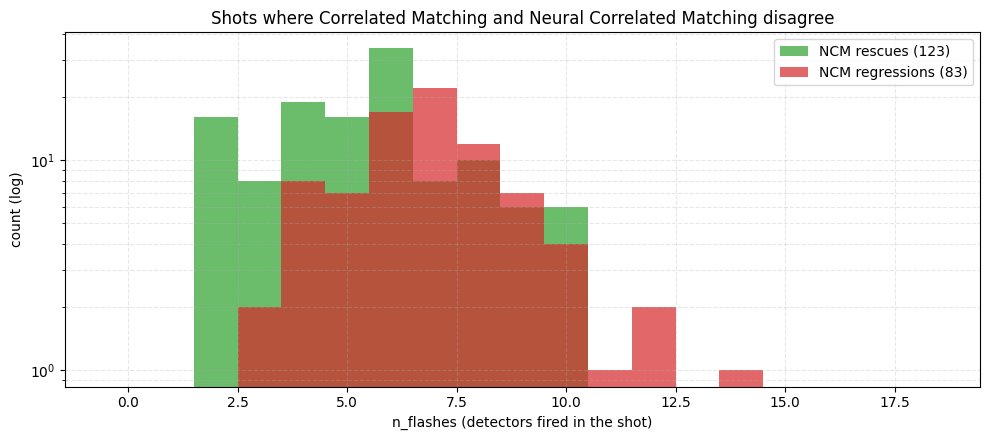

   n_flashes     rescues     regressions       net
--------------------------------------------------
           0           0               0        +0
           1           0               0        +0
           2          16               0       +16
           3           8               2        +6
           4          19               8       +11
           5          16               7        +9
           6          34              17       +17
           7           8              22       -14
           8          10              12        -2
           9           6               7        -1
       10-18           6               8        -2


In [14]:
import matplotlib.pyplot as plt

# n_flashes is already populated by the disagreement cell above.
ncm_rescue  = ~cm_correct &  ncm_correct   # NCM right, CM wrong
ncm_regress =  cm_correct & ~ncm_correct   # NCM wrong, CM right

# ----- histogram -----
max_f = int(n_flashes.max())
bins  = np.arange(0, max_f + 2) - 0.5

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(n_flashes[ncm_rescue],  bins=bins, alpha=0.7,
        label=f"NCM rescues ({ncm_only:,})", color="tab:green")
ax.hist(n_flashes[ncm_regress], bins=bins, alpha=0.7,
        label=f"NCM regressions ({cm_only:,})", color="tab:red")
ax.set_xlabel("n_flashes (detectors fired in the shot)")
ax.set_ylabel("count (log)")
ax.set_yscale("log")
ax.set_title("Shots where Correlated Matching and Neural Correlated Matching disagree")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

# ----- per-bucket table -----
edges = list(range(0, 11)) + [max_f + 1]    # 0,1,2,...,9,10,11+
print(f"{'n_flashes':>12}  {'rescues':>10}  {'regressions':>14}  {'net':>8}")
print("-" * 50)
for lo, hi in zip(edges[:-1], edges[1:]):
    mask = (n_flashes >= lo) & (n_flashes < hi)
    r = int(np.sum(ncm_rescue  & mask))
    g = int(np.sum(ncm_regress & mask))
    label = f"{lo}" if hi == lo + 1 else f"{lo}-{hi-1}"
    print(f"{label:>12}  {r:>10,}  {g:>14,}  {r - g:>+8}")